# [Bacterial Colony Growth](@id Bacteries)

In this example, we are going to create a bacterial model and grow a colony using it.

 - The implementation of the force interaction dynamics is the one presented by [Volfson et al. (2008)](https://www.pnas.org/doi/abs/10.1073/pnas.0706805105)
 - We use GPU accelerated dynamics

As described in other models, it is advised that the models are constructed by parts to avoid having to find bugs in a very complex system. Hence, we will split the model in two parts:

 - Forces model
 - Growth model

## Load the packages

In [34]:
using Base.Threads
println("Usando ", nthreads(), " threads 😎")

Usando 1 threads 😎


In [35]:
# import Pkg
# Pkg.activate("../")
# Pkg.instantiate()


In [36]:
# import Pkg; Pkg.add(["Revise", "GLMakie"])

In [37]:
# using Revise
# using CellBasedModels
# using CUDA
# using Distributions
# using GLMakie
# # using GeometryBasics
# import GLMakie: Point3f, Cylinder, Sphere, NoShading #Can be changes to Cairo or CLMakie

In [38]:
import Pkg

# Activa el entorno del proyecto
Pkg.activate("../../../")


# Resuelve y asegura dependencias
Pkg.resolve()
Pkg.instantiate()


# Carga los paquetes de forma ordenada
using Revise
using CellBasedModels
ENV["JULIA_CUDA_USE_BINARYBUILDER"] = false  # (opcional, fuerza compilación local)
using CUDA
CUDA.set_runtime_version!(v"12.2")
using Distributions
using CairoMakie
using JSON

# Importa funciones específicas después
import CairoMakie: Point3f, Cylinder, Sphere, NoShading

CairoMakie.activate!()


  Activating project at `~/Escritorio/Projects/Pushing/ABM_CBM`
  No Changes to `~/Escritorio/Projects/Pushing/ABM_CBM/Project.toml`
  No Changes to `~/Escritorio/Projects/Pushing/ABM_CBM/Manifest.toml`
┌ Info: Configure the active project to use CUDA 12.2; please re-start Julia for this to take effect.
└ @ CUDA /home/julia/.julia/packages/CUDA/jdJ7Z/lib/cudadrv/version.jl:82


## Forces model

We already use the defined forces model that is implemented in CBqodels. This is an exact copy of the rod model that you can find already predefined in `Models/rods.jl`. You can check the `Models` section of the documentation for more details.


In [39]:
rod2D = ABM(2,
    agent = Dict(
            :theta=>Float64,
            :d=>Float64,
            :l=>Float64,
            :fx=>Float64,
            :fy=>Float64,
            :W=>Float64,
            :eta=>Float64,
        ),    #Local Interaction Parameters

    model = Dict(
            :E=>Float64,
        ),        #Global parameters

    agentODE = quote

        fx = 0
        fy = 0
        W = 0
        @loopOverNeighbors i2 begin

            #Use the model provided in the documentation
            Fijx, Fijy, Wij = CBMModels.repulsiveForces_rods(x,y,d,l,theta,
                                    x[i2],y[i2],d[i2],l[i2],theta[i2],eta, E)

            #Append the repulsive forces
            fx += Fijx
            fy += Fijy
            W += Wij
            
        end

        #Equations
        dt(x) =  fx 
        dt(y) =  fy 
        dt(theta) =  W
    end,

    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=4),
    platform=GPU(),
    agentAlg = CBMIntegrators.Heun()
);


### Initialize a coqunity with two bacteries and check forces

In [40]:
com = Community(rod2D,
            N=30,
            dt=0.0001,
            simBox = [-10 10;-10 10.],
            );


#Natural units scales
m = 1.E3 #g
t = 1/(60*60) # h
d = 1.E6 #um


com.E=6* 1.E5 *m/(t^2*d) #Pa
com.eta=150 *m/(t^2*d) #Pa h
 

com.d = 1.        
com.l = 3.99      



com.x = 0
com.y = 0
com.theta = 0;


In [41]:
com.N

30

In [42]:
for i in 1:com.N
    com.theta[i] = rand() * 2π
    com.x[i] = rand()*10-5
    com.y[i] = rand()*10-5
    com.l[i] = 3.0
    com.d[i] = 1.0

end

In [43]:
evolve!(com,steps=10000,saveEach=100,preallocateAgents=com.N)

In [44]:
function plotAgents2D!(ax, x, y, d, l, angle, p; colormap=:inferno, kargs...)
    for (xi, yi, li, di, ai, pi) in zip(x, y, l, d, angle, p)



            colorval = pi
            # colormap = :inferno
            meshscatter!(ax,
                [xi + li/2 * cos(ai)],
                [yi + li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [colorval],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi - li/2 * cos(ai)],
                [yi - li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [colorval],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi],
                [yi];
                marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
                markersize = [Point3f(li, di/2, di/2)],
                rotation = [ai],
                color = [colorval],
                colormap = colormap,
                kargs...
            )

    end
    return
end


plotAgents2D! (generic function with 1 method)

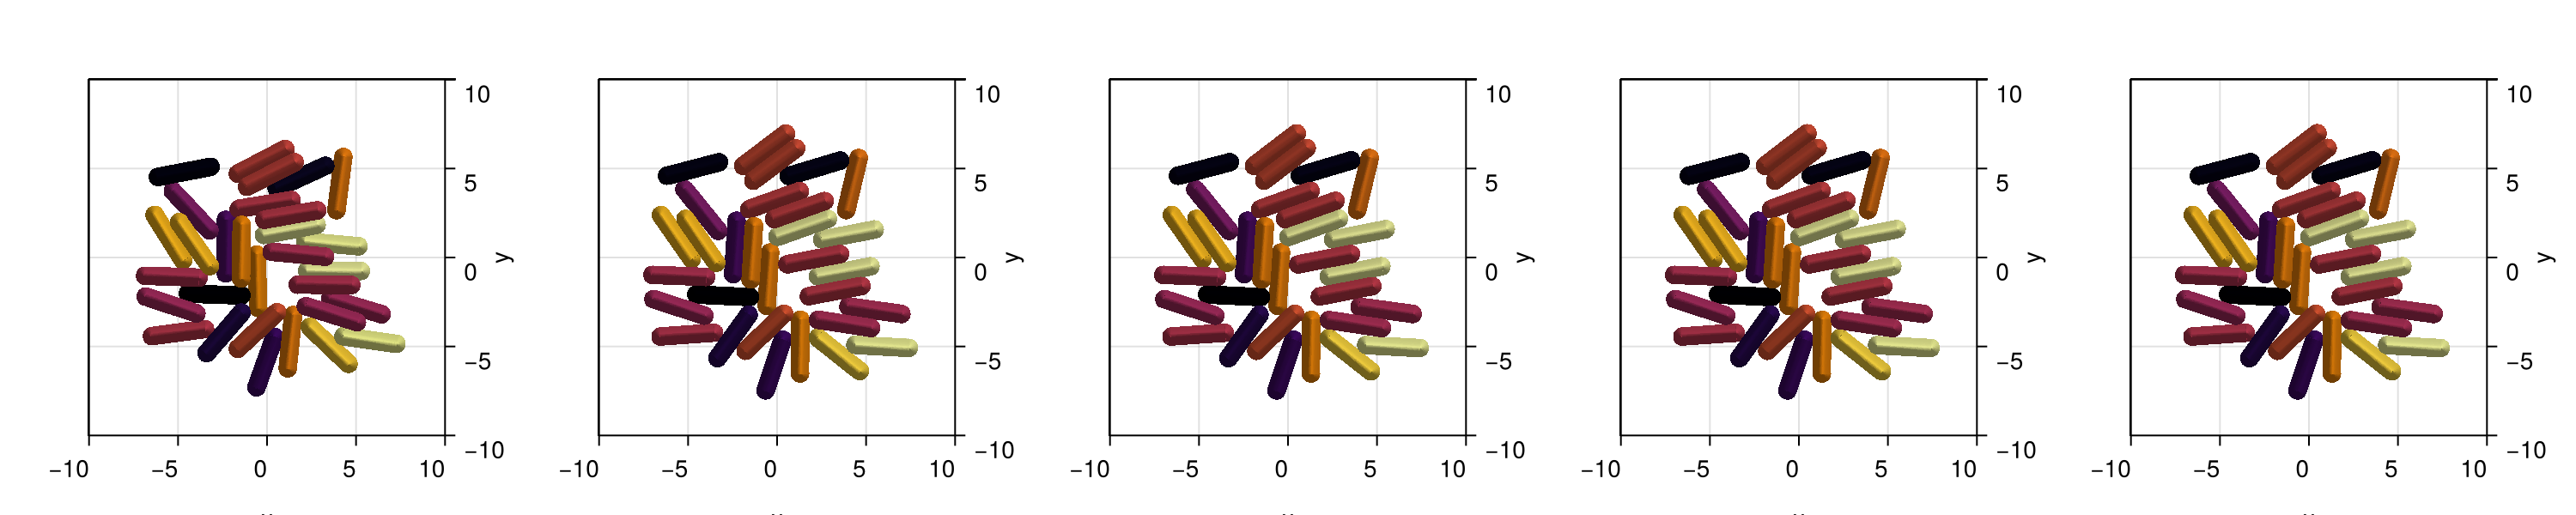

CairoMakie.Screen{IMAGE}


In [45]:
fig = Figure(size=(1500,300))

for (i,j) in enumerate([1:round(Int,length(com)/4):length(com);length(com)])
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotAgents2D!(
    ax,
    com[j][:x],
    com[j][:y],
    com[j][:d],
    com[j][:l],
    com[j][:theta],
    com[j][:theta],
    colorrange = (0, 2*pi)
)

    xlims!(-10,10)
    ylims!(-10,10)
end

display(fig)

In [46]:

function log_community_state(parameters::OrderedDict, t::Int, path::String = "Tods_c.txt")
    # Convert keys to strings so JSON can serialize them
    string_keys = Dict(string(k) => v for (k, v) in parameters)
    # Build entry
    entry = Dict("t" => t, "parameters" => string_keys)
    # Save as a JSON line
    open(path, "a") do io
        println(io, JSON.json(entry))
    end
end


function load_parameters_log(path::String = "Tods_c.txt")
    log = Dict{Int, OrderedDict{Symbol, Any}}()
    for line in eachline(path)
        entry = JSON.parse(line)
        t = entry["t"]
        raw_params = entry["parameters"]
        params = OrderedDict(Symbol(k) => v for (k, v) in raw_params)
        log[t] = params
    end
    times = sort(collect(keys(log)))
    com_array = [log[t] for t in times]
    return com_array, times
end



load_parameters_log (generic function with 2 methods)

## Growth model

We construct over the forces model to add bacterial growth and cell division rules.

In [47]:
function plotMixedAgents2D!(ax, x, y, d, l, angle, type, p; kargs...)
    for (xi, yi, li, di, ai, ti, pi) in zip(x, y, l, d, angle, type, p)


        if ti== 0  # rods
            # colorval = pi
            # colormap = :Blues
            meshscatter!(ax,
                [xi + li/2 * cos(ai)],
                [yi + li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [:blue],
                # colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi - li/2 * cos(ai)],
                [yi - li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [:blue],

                # colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi],
                [yi];
                marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
                markersize = [Point3f(li, di/2, di/2)],
                rotation = [ai],
                color = [:blue],

                kargs...
            )
        else  # puntos
            colorval = pi
            colormap = :Reds
            meshscatter!(ax,
                [xi + li/2 * cos(ai)],
                [yi + li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [:red],
                kargs...
            )
            meshscatter!(ax,
                [xi - li/2 * cos(ai)],
                [yi - li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [:red],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi],
                [yi];
                marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
                markersize = [Point3f(li, di/2, di/2)],
                rotation = [ai],
                color = [:red],
                colormap = colormap,
                kargs...
            )
        end

    end
    return
end


plotMixedAgents2D! (generic function with 1 method)

In [48]:
rods2dGrowth = ABM(2,
    baseModelInit = [rod2D],

    agent = Dict(
                :dg=> Float64, 
                :lTarget => Float64,
                :type => Int,
                :growth=>Float64,
                :generation => Int,
                :v => Float64, 
            ),

    model = Dict(
                :σlTarget=>Float64,
                :lMax=>Float64,
                :D_PGA=>Float64, #Diffusion coefficient for the medium
                :delta_PGA=>Float64, #Decay rate of the medium
                :alpha_PGA=>Float64, #Decay rate of the cells in the medium
            ),
    
    medium = Dict(
        :PGA => Float64,        #Add a medium parameter
        :Hx => Float64,  #Add a medium parameter
        :Hy => Float64        #Add a medium parameter
    ),

 
    agentODE = quote    
        dt(l) = l*growth #linear growth with growth dependent on the pressure over the cell

        fx = 0
        fy = 0
        W = 0
        @loopOverNeighbors i2 begin
            #Use the model provided in the documentation
            Fijx, Fijy, Wij = CBMModels.repulsiveForces_rods(x,y,d,l,theta,
                                    x[i2],y[i2],d[i2],l[i2],theta[i2],eta, E)

            #Append the repulsive forces
            fx += Fijx
            fy += Fijy
            W += Wij

            fx-= v * Hx
            fy-= v * Hy
            

            
        end
        #Equations
        dt(x) =  fx 
        dt(y) =  fy 
        dt(theta) =  W
    end,

    agentRule = quote #Bound cells
        #Add division
        if l > lTarget
            ww = CBMDistributions.uniform(-1,1)*1.E-2 #To add some random torque at division time

            # ww = 0 #To add some random torque at division time
            #Add a new cell
            @addAgent(
                    x=(l+d)/4*cos(theta)+x,
                    y=(l+d)/4*sin(theta)+y,
                    l=(l-d)/2,
                    W=ww,
                    lTarget = CBMDistributions.uniform(lMax-σlTarget,lMax+σlTarget),
                    dg=dg,
                    generation = generation + 1)
            #Add a second cell
            @addAgent(
                    x=-(l+d)/4*cos(theta)+x,
                    y=-(l+d)/4*sin(theta)+y,
                    l=(l-d)/2,
                    lTarget = CBMDistributions.uniform(lMax-σlTarget,lMax+σlTarget), #New target length at which the bactery should divide
                    W=ww,
                    dg=dg,
                    generation = generation + 1)
            #Remove the old cell
            @removeAgent()
        end
        
        if type !=0
            PGA += (alpha_PGA)*dt
        end
  
    end,

    #Medium dynamics with dirichlet conditions and a wall that is as oscillating source of material
    mediumODE=quote 
        if @mediumInside()
            dt(PGA) = D_PGA*(@∂2(1,PGA)+@∂2(2,PGA)) - delta_PGA*PGA
            Hx = @∂(1,PGA) 
            Hy = @∂(2,PGA)
        elseif @mediumBorder(1,-1)
            PGA = 0
        elseif @mediumBorder(1,1)
            PGA = 0
        elseif @mediumBorder(2,-1)
            PGA = 0
        elseif @mediumBorder(2,1)
            PGA = 0
        end

    end,

    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=4),
    platform=GPU(),
    agentAlg=CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler(),
);

## Grow colony from one cell

In [49]:
com = Community(rods2dGrowth,
            N=1,
            dt=0.0001,
            simBox = [-100 100;-100 100.],
            NMedium=[200,200],
            );

#Natural units scales
m = 1.E3 #g
t = 1/(60*60) # h
d = 1.E6 #um


com.E=1* 1.E6 *m/(t^2*d) #Pa
com.eta=200 *m/(t^2*d) #Pa h
 
com.PGA=0
com.alpha_PGA = 10
com.delta_PGA = 1
com.D_PGA = 20
com.v =1

com.growth = 5
com.lMax = 4.     
com.σlTarget = 1. 
com.generation = 0 
 
com.d = 1.        
com.l = 3.99      
com.lTarget = 4.  


com.x = 0
com.y = 0
com.theta = 0;

In [50]:
steps=Int(round(2/com.dt))
# saveEach=steps/100
saveEach=Int(round(10/com.dt))/100
# steps=100000
# saveEach=10000
N=100 

loadToPlatform!(com,preallocateAgents=N)
open("Tods_c.txt", "w") do f
    # clear file at start
end

for step in 1:steps
    
    step!(com)

    if step % saveEach == 0
        bringFromPlatform!(com)
        if N - com.N[1] <= 0
                println("Step ",step, " N: ", com.N[1], " preallocateAgents: ", N)
                @warn "More agents than preallocateAgents, stopping simulation."
                break
        elseif   N - com.N[1]  < 4*com.N[1]
                N = 15*com.N[1]
        end 
        println("Step ",step, " N: ", com.N[1])
        log_community_state(com.parameters, step)
        loadToPlatform!(com,preallocateAgents=N)
    end
end

bringFromPlatform!(com)


Step 1000 N: 2
Step 2000 N: 4
Step 3000 N: 4
Step 4000 N: 5
Step 5000 N: 8
Step 6000 N: 12
Step 7000 N: 16
Step 8000 N: 28
Step 9000 N: 32
Step 10000 N: 55
Step 11000 N: 64
Step 12000 N: 100
Step 13000 N: 128
Step 14000 N: 202
Step 15000 N: 263
Step 16000 N: 420
Step 17000 N: 520
Step 18000 N: 843
Step 19000 N: 1060
Step 20000 N: 1667


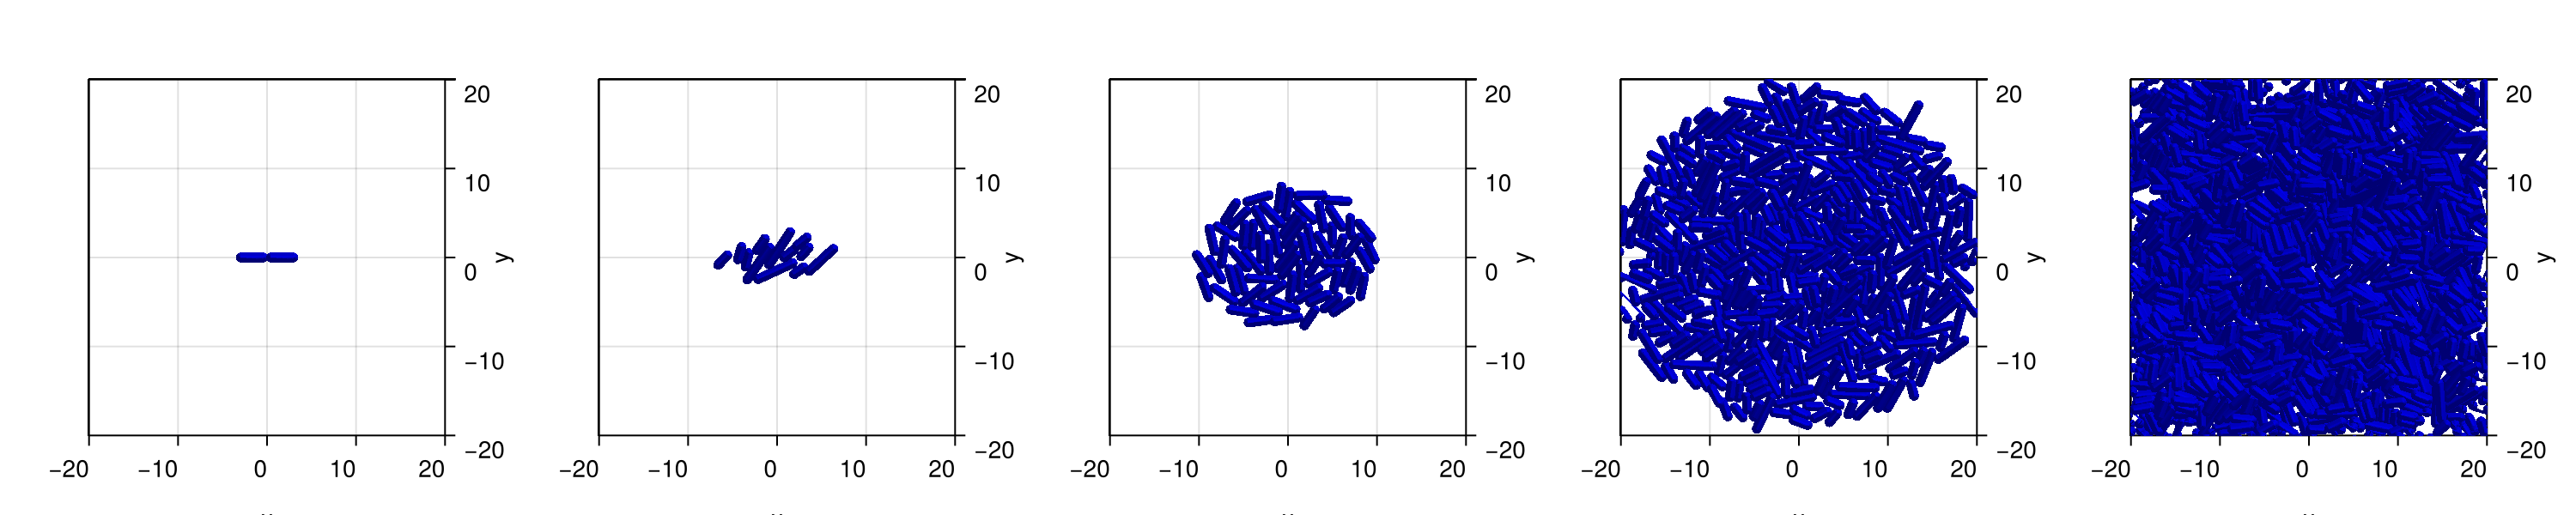

CairoMakie.Screen{IMAGE}


In [51]:
com_load,times=load_parameters_log("Tods_c.txt")

fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    xlims!(-20,20)
    ylims!(-20,20)
end

display(fig)

In [52]:

prev_steps=steps
steps=Int(round(3/com.dt))
com.growth = 0

loadToPlatform!(com,preallocateAgents=N)


for step in 1+prev_steps:steps
    
    step!(com)

    if step % saveEach == 0
        bringFromPlatform!(com)
        if N - com.N[1] <= 0
                println("Step ",step, " N: ", com.N[1], " preallocateAgents: ", N)
                @warn "More agents than preallocateAgents, stopping simulation."
                break
        elseif   N - com.N[1]  < 4*com.N[1]
                N = 15*com.N[1]
        end 
        println("Step ",step, " N: ", com.N[1])
        log_community_state(com.parameters, step)
        loadToPlatform!(com,preallocateAgents=N)
    end
end
bringFromPlatform!(com)


Step 21000 N: 1667
Step 22000 N: 1667
Step 23000 N: 1667
Step 24000 N: 1667
Step 25000 N: 1667
Step 26000 N: 1667
Step 27000 N: 1667
Step 28000 N: 1667
Step 29000 N: 1667
Step 30000 N: 1667


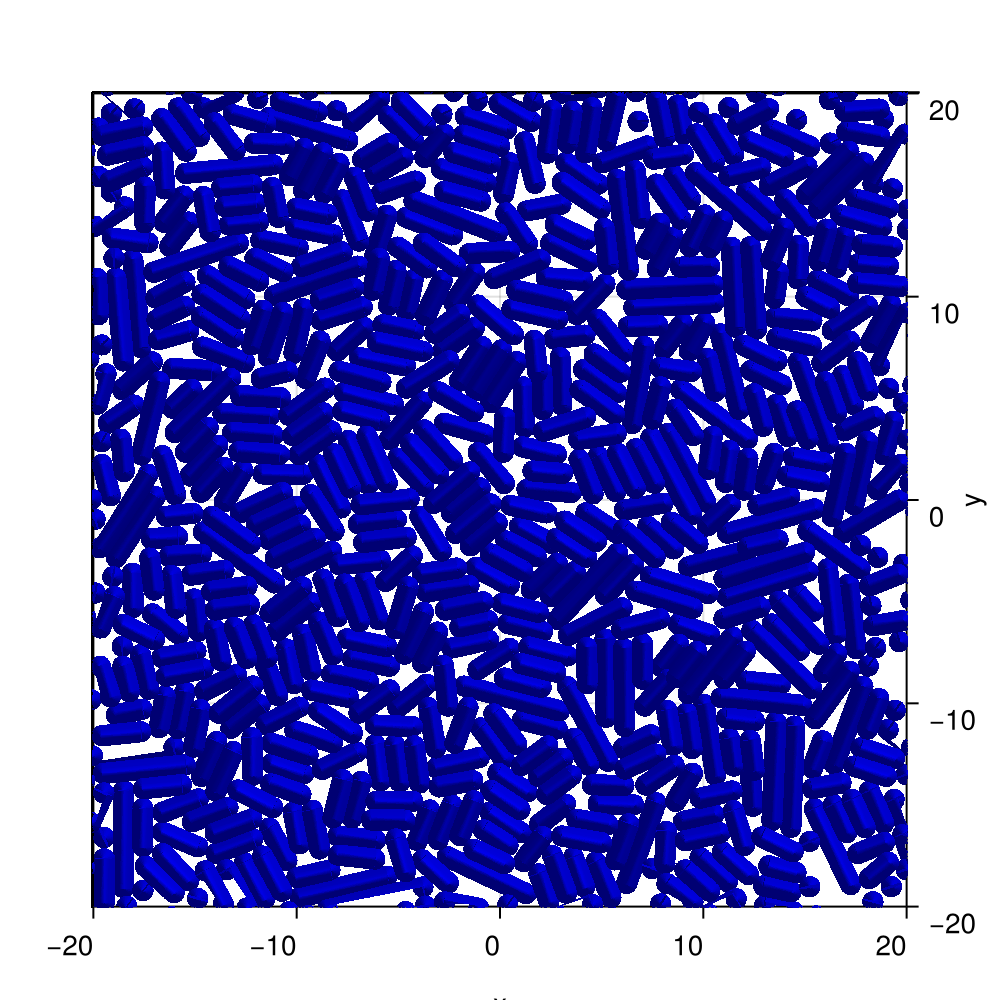

CairoMakie.Screen{IMAGE}


In [53]:
com_load,times=load_parameters_log("Tods_c.txt")

fig = Figure(size=(500,500))

js = length(com_load)
# js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    xlims!(-20,20)
    ylims!(-20,20)
end

display(fig)

In [54]:
# cx, cy = 0, 15
# R2 = 100  # comparamos con el cuadrado del radio para evitar sqrt
# com.growth = 0.2
com.type =0
rmax = 0
for i in range(1,length(com.x))
    r = com.x[i]^2 + com.y[i]^2
    if r > rmax
        rmax = r
    end
    theta = atan(com.y[i], com.x[i])
    R =  400*exp(-50*theta^(2))+ 400
    prob = R^6/(R^6+r^6)
    if prob > rand()
        com.type[i] = 1
    else
        com.type[i] = 0
    end
end

println(sum(com.type .== 1))
log_community_state(com.parameters, steps)
com_load,times=load_parameters_log("Tods_c.txt")




448


(OrderedDict{Symbol, Any}[OrderedDict(:W => Any[3.018075949512422e-5, 3.018075949512422e-5], :D_PGA => Any[20.0], :fx => Any[-6.03084135055542, 6.03084135055542], :x => Any[-1.7077271938323975, 1.7077271938323975], :σlTarget => Any[1.0], :theta => Any[8.979312156043306e-7, 8.979312156043306e-7], :PGA => Any[Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

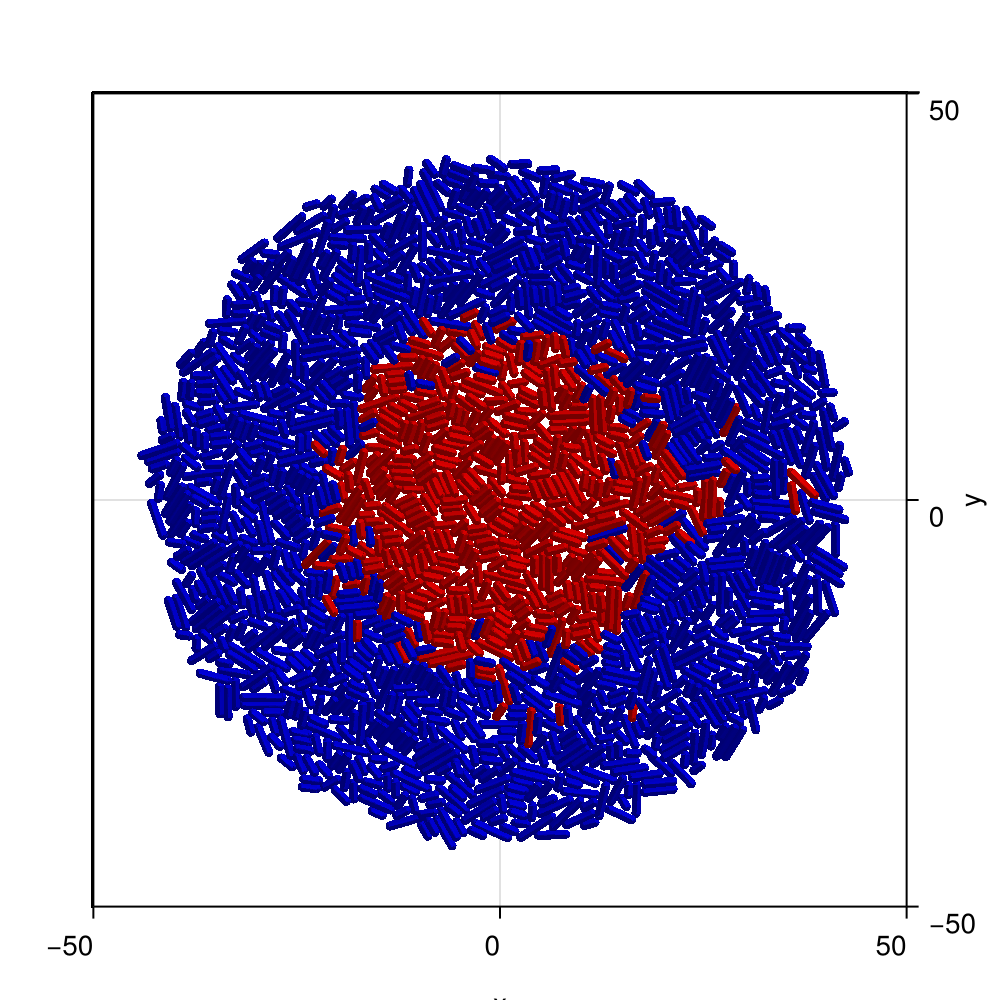

CairoMakie.Screen{IMAGE}


In [55]:
fig = Figure(size=(500,500))

# js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]
js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    xlims!(-50,50)
    ylims!(-50,50)
end

display(fig)

In [56]:
open("Motiles.txt", "w") do f
    # clear file at start
end
bringFromPlatform!(com)

com.PGA=0
com.alpha_PGA = 10
com.delta_PGA = 1
com.D_PGA = 20

com.v =0

log_community_state(com.parameters, steps, "Motiles.txt")

In [57]:
prev_steps=steps
steps=Int(round(3/com.dt))
com.growth = 0

loadToPlatform!(com,preallocateAgents=N)


for step in 1+0:steps
    
    step!(com)

    if step % saveEach == 0
        bringFromPlatform!(com)
        if N - com.N[1] <= 0
                println("Step ",step, " N: ", com.N[1], " preallocateAgents: ", N)
                @warn "More agents than preallocateAgents, stopping simulation."
                break
        elseif   N - com.N[1]  < 4*com.N[1]
                N = 15*com.N[1]
        end 
        println("Step ",step, " N: ", com.N[1])
        log_community_state(com.parameters, step, "Motiles.txt")
        loadToPlatform!(com,preallocateAgents=N)
    end
end
bringFromPlatform!(com)


Step 1000 N: 1667
Step 2000 N: 1667
Step 3000 N: 1667
Step 4000 N: 1667
Step 5000 N: 1667
Step 6000 N: 1667
Step 7000 N: 1667
Step 8000 N: 1667
Step 9000 N: 1667
Step 10000 N: 1667
Step 11000 N: 1667
Step 12000 N: 1667
Step 13000 N: 1667
Step 14000 N: 1667
Step 15000 N: 1667
Step 16000 N: 1667
Step 17000 N: 1667
Step 18000 N: 1667
Step 19000 N: 1667
Step 20000 N: 1667
Step 21000 N: 1667
Step 22000 N: 1667
Step 23000 N: 1667
Step 24000 N: 1667
Step 25000 N: 1667
Step 26000 N: 1667
Step 27000 N: 1667
Step 28000 N: 1667
Step 29000 N: 1667
Step 30000 N: 1667


In [58]:
com_load,times=load_parameters_log("Motiles.txt")


(OrderedDict{Symbol, Any}[OrderedDict(:W => Any[6.729219436645508, 36.721927642822266, 0.010728953406214714, 2.100841522216797, 1.136609435081482, -4.31727409362793, 0.7683179974555969, -4.886907577514648, 21.37467384338379, 2.513099431991577  …  2.0101370811462402, 6.950000762939453, -63.02538299560547, 0.26869940757751465, 14.747121810913086, -3.346780776977539, -1.7813974618911743, -25.80984115600586, 10.484622955322266, 19.535282135009766], :D_PGA => Any[20.0], :fx => Any[0.8700436949729919, 1.3785591125488281, 0.3669299781322479, -0.7476503252983093, -0.8442363142967224, -0.646664559841156, -0.012965448200702667, 3.8448729515075684, -0.2665199637413025, -1.6600642204284668  …  0.8493578433990479, 0.5898866653442383, -0.9328112602233887, -1.1653610467910767, 0.022618524730205536, -1.3596317768096924, 3.9434211254119873, 1.3672702312469482, 0.429508239030838, 10.286386489868164], :x => Any[-29.837871551513672, 2.334965229034424, 6.430449485778809, -33.09373474121094, -36.54296493530

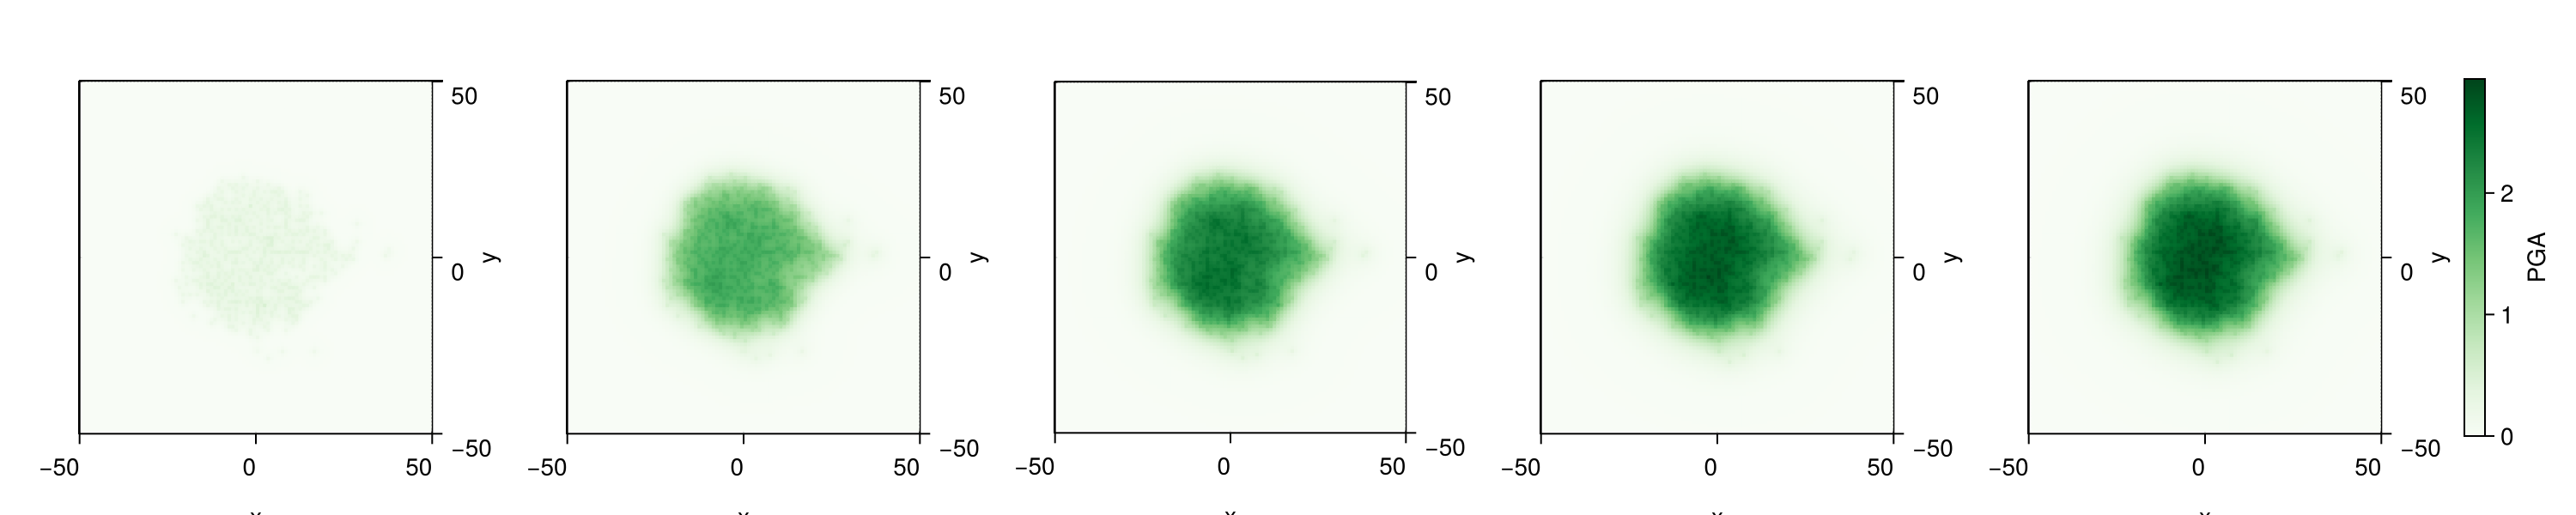

CairoMakie.Screen{IMAGE}


In [59]:
# Colormap común y colorrange fijo
# colormap = :viridis
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colormap_PGA=:Greens
colorrange_PGA = (0.0,  maximum(maximum(p -> maximum(p[:PGA]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.PGA)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.PGA)[1]),
                Float64.(hcat(com_load[j][:PGA]...)),
                colormap = colormap_PGA,
                colorrange = colorrange_PGA
            )
    



    xlims!(-50,50)
    ylims!(-50,50)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_PGA,
    colorrange = colorrange_PGA,
    label = "PGA"
)

display(fig)

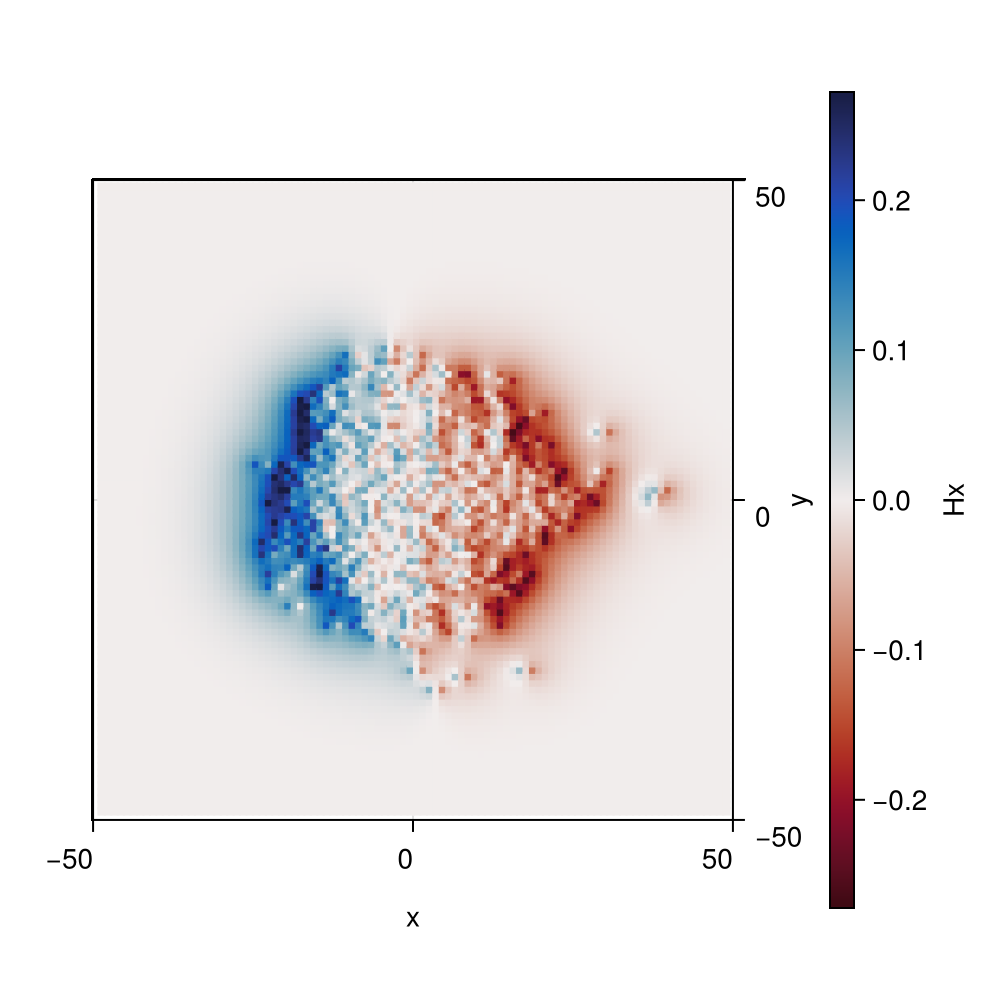

CairoMakie.Screen{IMAGE}


In [60]:
# Colormap común y colorrange fijo
colormap = Reverse(:balance)
minval= minimum(minimum(p -> minimum(p[:Hx]), com_load))
maxval= maximum(maximum(p -> maximum(p[:Hx]), com_load))
maxrange= maximum(abs.([minval, maxval]))
colorrange = (-maxrange, maxrange)

fig = Figure(size=(500,500))

js =length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.Hx)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.Hx)[1]),
                Float64.(hcat(com_load[j][:Hx]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    # plotMixedAgents2D!(
    # ax,
    # com_load[j][:x],
    # com_load[j][:y],
    # com_load[j][:d],
    # com_load[j][:l],
    # com_load[j][:theta],
    # com_load[j][:type],
    # com_load[j][:pressure],
    # colorrange = (0, 0.03)
    # )

    xlims!(-50,50)
    ylims!(-50,50)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "Hx"
)

display(fig)

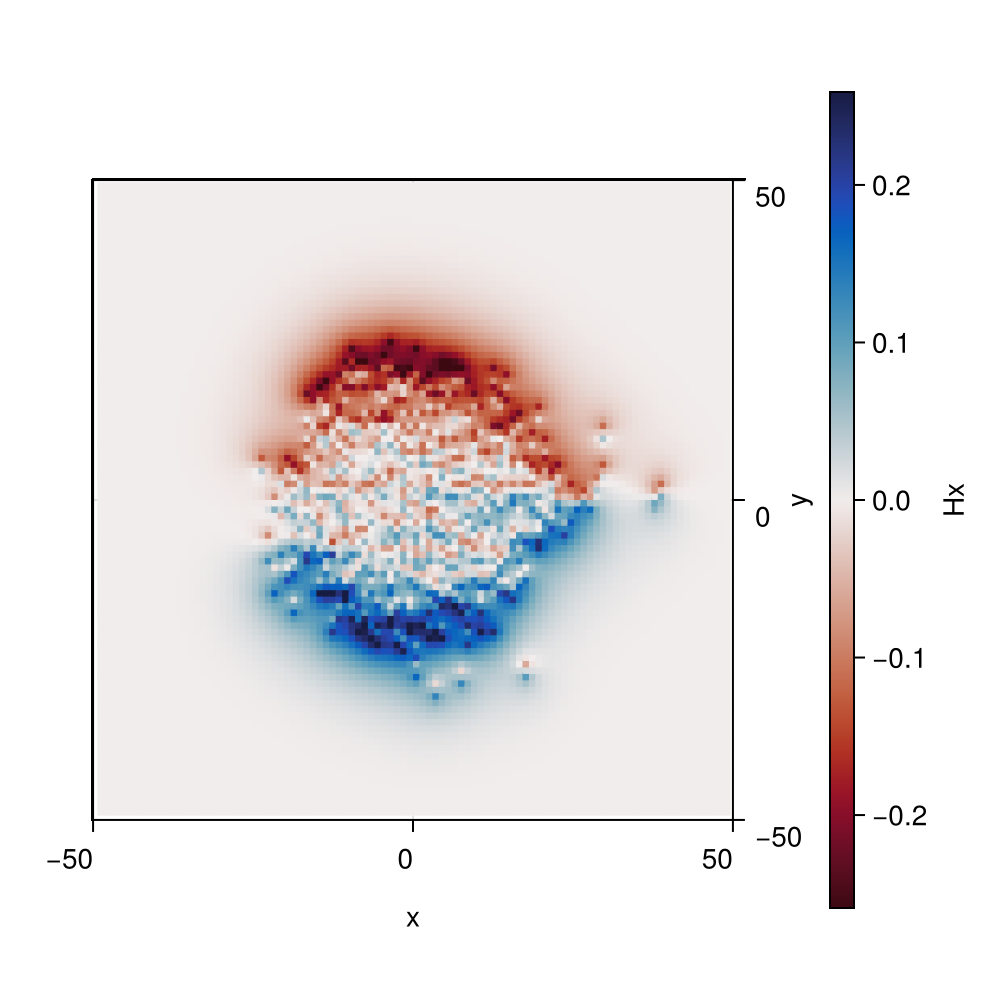

CairoMakie.Screen{IMAGE}


In [61]:
# Colormap común y colorrange fijo
colormap = Reverse(:balance)
minval= minimum(minimum(p -> minimum(p[:Hy]), com_load))
maxval= maximum(maximum(p -> maximum(p[:Hy]), com_load))
maxrange= maximum(abs.([minval, maxval]))
colorrange = (-maxrange, maxrange)

fig = Figure(size=(500,500))

js =length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.Hy)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.Hy)[1]),
                Float64.(hcat(com_load[j][:Hy]...)),
                colormap = colormap,
                colorrange = colorrange
            )
    

    # plotMixedAgents2D!(
    # ax,
    # com_load[j][:x],
    # com_load[j][:y],
    # com_load[j][:d],
    # com_load[j][:l],
    # com_load[j][:theta],
    # com_load[j][:type],
    # com_load[j][:pressure],
    # colorrange = (0, 0.03)
    # )

    xlims!(-50,50)
    ylims!(-50,50)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap,
    colorrange = colorrange,
    label = "Hx"
)

display(fig)

In [62]:
open("Motiles.txt", "w") do f
    # clear file at start
end
bringFromPlatform!(com)

com.v = 0.5

log_community_state(com.parameters, steps, "Motiles.txt")

In [72]:
prev_steps=33000
steps=Int(round(10/com.dt))
com.growth = 0.0
com.v = 0.2

loadToPlatform!(com,preallocateAgents=N)


for step in 1+prev_steps:steps
    
    step!(com)

    if step % saveEach == 0
        bringFromPlatform!(com)
        if N - com.N[1] <= 0
                println("Step ",step, " N: ", com.N[1], " preallocateAgents: ", N)
                @warn "More agents than preallocateAgents, stopping simulation."
                break
        elseif   N - com.N[1]  < 4*com.N[1]
                N = 15*com.N[1]
        end 
        println("Step ",step, " N: ", com.N[1])
        log_community_state(com.parameters, step, "Motiles.txt")
        loadToPlatform!(com,preallocateAgents=N)
    end
end
bringFromPlatform!(com)


Step 34000 N: 1667
Step 35000 N: 1667
Step 36000 N: 1667
Step 37000 N: 1667
Step 38000 N: 1667
Step 39000 N: 1667
Step 40000 N: 1667
Step 41000 N: 1667
Step 42000 N: 1667
Step 43000 N: 1667
Step 44000 N: 1667
Step 45000 N: 1667
Step 46000 N: 1667
Step 47000 N: 1667
Step 48000 N: 1667
Step 49000 N: 1667
Step 50000 N: 1667
Step 51000 N: 1667
Step 52000 N: 1667
Step 53000 N: 1667
Step 54000 N: 1667
Step 55000 N: 1667
Step 56000 N: 1667
Step 57000 N: 1667
Step 58000 N: 1667
Step 59000 N: 1667
Step 60000 N: 1667
Step 61000 N: 1667
Step 62000 N: 1667
Step 63000 N: 1667
Step 64000 N: 1667
Step 65000 N: 1667
Step 66000 N: 1667
Step 67000 N: 1667
Step 68000 N: 1667
Step 69000 N: 1667
Step 70000 N: 1667
Step 71000 N: 1667
Step 72000 N: 1667
Step 73000 N: 1667
Step 74000 N: 1667
Step 75000 N: 1667
Step 76000 N: 1667
Step 77000 N: 1667
Step 78000 N: 1667
Step 79000 N: 1667
Step 80000 N: 1667
Step 81000 N: 1667
Step 82000 N: 1667
Step 83000 N: 1667
Step 84000 N: 1667
Step 85000 N: 1667
Step 86000 N

In [73]:
com_load,times=load_parameters_log("Motiles.txt")


(OrderedDict{Symbol, Any}[OrderedDict(:W => Any[0.03579283878207207, -0.6720467805862427, 0.004583272151648998, -0.6610364317893982, 0.018495962023735046, 0.6556819081306458, -0.09643267840147018, 0.03173419088125229, -1.3227440118789673, -0.18344320356845856  …  -0.9855020642280579, 0.3964286744594574, -0.05929975584149361, -0.0010273612570017576, 0.1480298936367035, -0.06439413130283356, 0.3769832253456116, 0.11779405921697617, 0.17322981357574463, -3.3610293865203857], :D_PGA => Any[20.0], :fx => Any[-0.20357204973697662, 0.19742876291275024, 0.01590423658490181, -0.4136926233768463, -0.07443034648895264, -0.020842505618929863, -0.28177177906036377, -0.09233207255601883, 0.08324774354696274, -0.352988064289093  …  0.9681625962257385, -0.22851194441318512, -0.7100681066513062, -0.03566070646047592, 0.011125199496746063, -0.12857753038406372, 1.1033190488815308, -0.5415639877319336, -0.3852245807647705, 0.15267810225486755], :x => Any[-30.770484924316406, 2.3863275051116943, 6.5912995

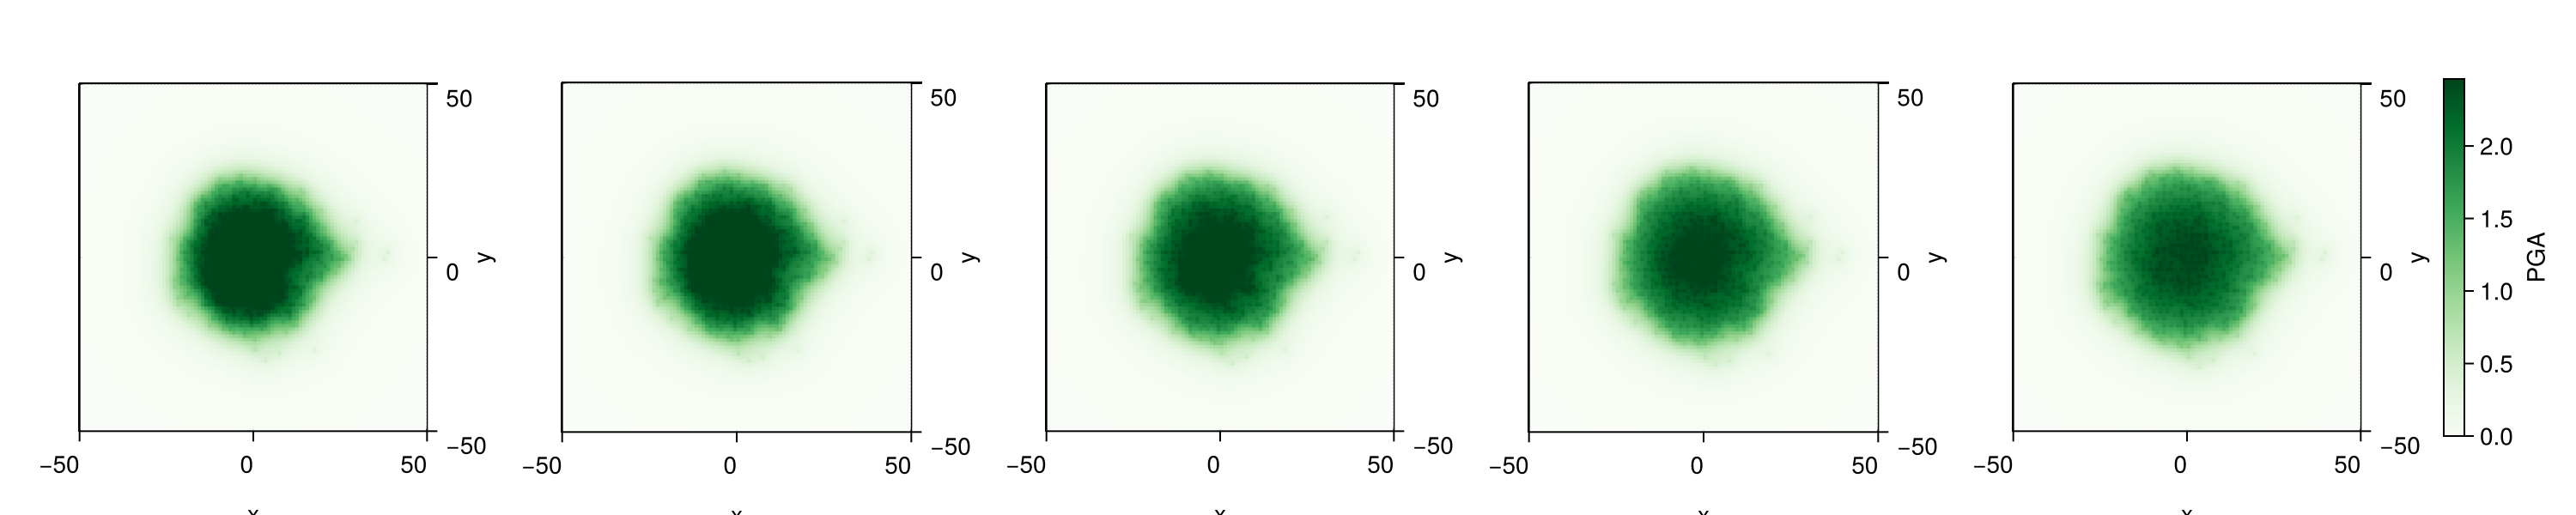

CairoMakie.Screen{IMAGE}


In [68]:
# Colormap común y colorrange fijo
# colormap = :viridis
simBox_cpu = Array(com.simBox)  # copia a CPU
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colormap_PGA=:Greens
colorrange_PGA = (0.0,  maximum(maximum(p -> maximum(p[:PGA]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.PGA)[1]),
                range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.PGA)[1]),
                Float64.(hcat(com_load[j][:PGA]...)),
                colormap = colormap_PGA,
                colorrange = colorrange_PGA
            )
    



    xlims!(-50,50)
    ylims!(-50,50)
end

# Añadir colorbar común al final
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_PGA,
    colorrange = colorrange_PGA,
    label = "PGA"
)

display(fig)

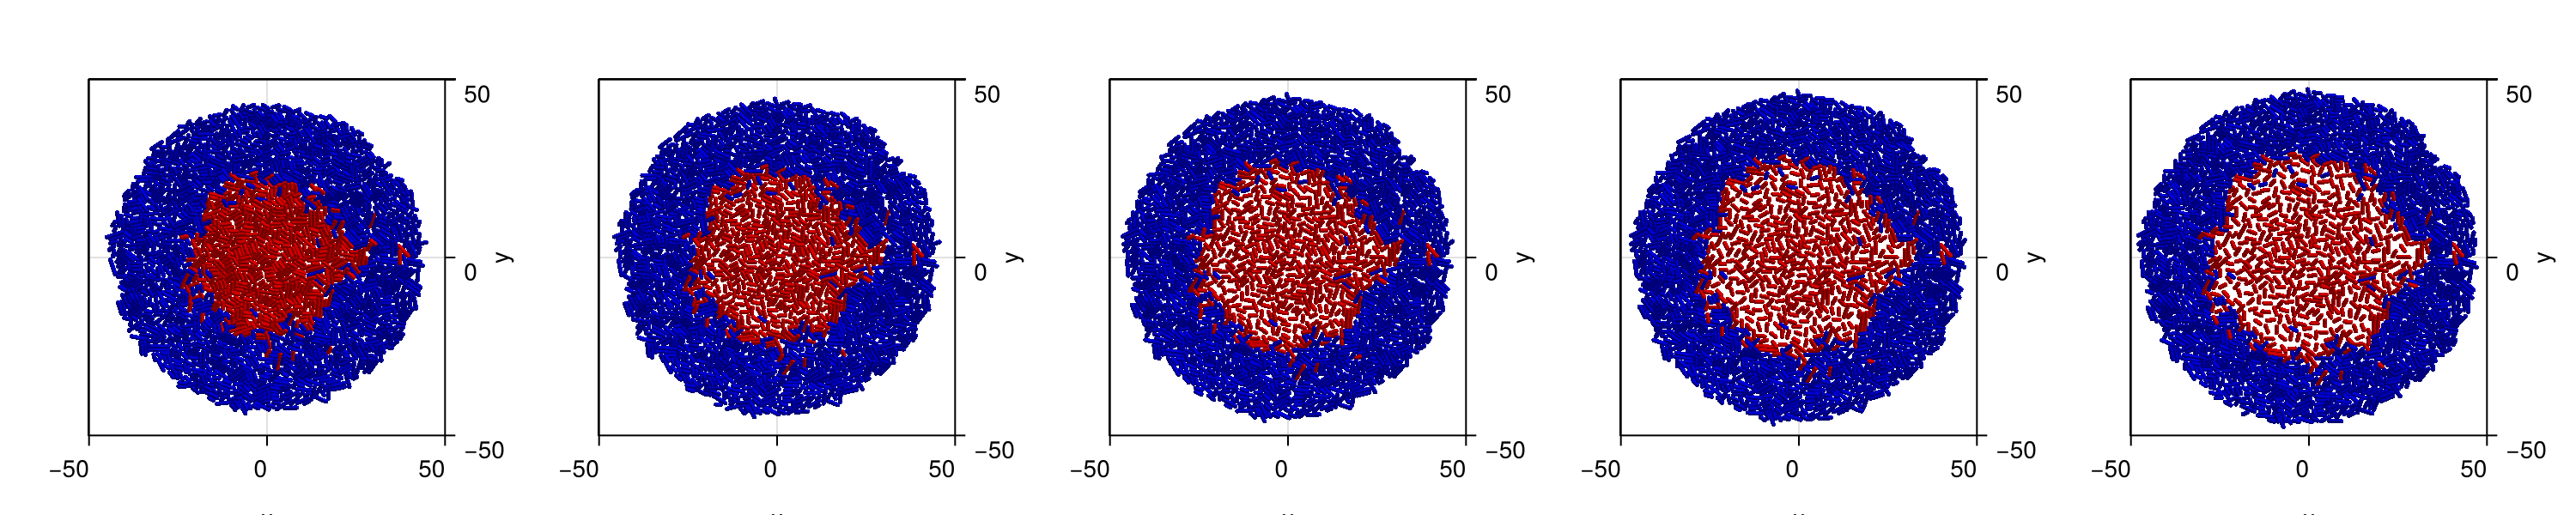

CairoMakie.Screen{IMAGE}


In [74]:
fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotMixedAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:theta],
    colorrange = (0, 0.03)
    )

    xlims!(-50,50)
    ylims!(-50,50)
end

display(fig)

In [70]:
function plotMixedAgents!(ax, x, y, d, l, angle, type, p; kargs...)
    # Diccionario de tipos a colormaps (puedes extenderlo con más tipos y colores)
    colormap_dict = Dict(
        0 => :Blues,
        1 => :Reds,
        2 => :Greens,
        3 => :Oranges,
        4 => :Purples,
        5 => :Greys
    )

    for (xi, yi, li, di, ai, ti, pi) in zip(x, y, l, d, angle, type, p)
        # Colormap según tipo, o uno genérico si no está definido
        colormap = get(colormap_dict, ti, :viridis)

        # Color numérico según p
        colorval = pi

        # Esferas en los extremos
        for dx in (-1, 1)
            meshscatter!(ax,
                [xi + dx * li/2 * cos(ai)],
                [yi + dx * li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = colorval,
                colormap = colormap,
                kargs...
            )
        end

        # Cuerpo alargado
        meshscatter!(ax,
            [xi],
            [yi];
            marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
            markersize = [Point3f(li, di/2, di/2)],
            rotation = [ai],
            color = colorval,
            colormap = colormap,
            kargs...
        )
    end
    return
end


plotMixedAgents! (generic function with 1 method)

In [ ]:
# Colormap común y colorrange fijo
# colormap = :viridis
colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colormap_c=:Oranges
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))


fig = Figure(size=(1500,300))

js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )
    m = heatmap!(ax,
                range(com.simBox[1,1],com.simBox[1,2],length=size(com.c)[1]),
                range(com.simBox[2,1],com.simBox[2,2],length=size(com.c)[1]),
                Float64.(hcat(com_load[j][:c]...)),
                colormap = colormap_c,
                colorrange = colorrange_c
            )
    

    plotMixedAgents!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:type],
    com_load[j][:generation],
    colorrange = colorrange
    )

    xlims!(-50,50)
    ylims!(-50,50)
end

# Añadir colorbar común al final
# Colorbar(fig[1, length(js) + 1],
#     colormap = colormap,
#     colorrange = colorrange,
#     label = "QS"
# )

display(fig)

In [45]:
function plot_evolution_by_type_from_positions(com)
    colormap_dict = Dict(
        0 => :Blues,
        1 => :Reds,
        2 => :Greens,
        3 => :Oranges,
        4 => :Purples,
        5 => :Greys
    )

    tipos = unique(com[end][:type])
    tipos = sort(tipos)[2:end]

    first_gen = Dict{Int, NamedTuple}()

    for t in sort(collect(keys(com)))
        for (i, ti) in enumerate(com[t][:type])
            if !(ti in keys(first_gen))
                first_gen[ti] = (
                    tiempo = t,
                    index = i,
                    x0 = com[t][:x][i],
                    y0 = com[t][:y][i]
                )
            end
        end
    end

    fig = Figure()
    ax = Axis(fig[1, 1], 
            xlabel = "θ",
            ylabel = "r",
            yreversed = true,
            )

    for t in sort(collect(keys(com)))
        com_t = com[t]

        for ti in tipos
            indices = findall(com_t[:type] .== ti)
            if isempty(indices)
                continue
            end

            f = first_gen[ti]
            x0, y0 = f.x0, f.y0
            gen0 = f.tiempo

            xs = com_t[:x][indices]
            ys = com_t[:y][indices]
            gens = fill(t - gen0, length(indices))

            distances = sqrt.((xs).^2 .+ (ys).^2)

            # Ángulo relativo calculado por desplazamiento
            angles = atan.(ys, xs)  



            colormap = haskey(colormap_dict, ti) ? colormap_dict[ti] : error("Tipo $ti no tiene colormap definido")

            scatter!(ax, angles, distances;
                color = gens,
                colormap = colormap,
                markersize = 10,
                label = "Tipo $ti",
                colorrange = (0, length(com)),
            )
        end
    end

    # axislegend(ax)
    return fig
end


plot_evolution_by_type_from_positions (generic function with 1 method)

In [46]:
function plot_evolution(com)
    colormap_dict = Dict(
        0 => :Blues,
        1 => :Reds,
        2 => :Greens,
        3 => :Oranges,
        4 => :Purples,
        5 => :Greys
    )

    tipos = unique(com[end][:type])
    tipos = sort(tipos)[2:end]

    first_gen = Dict{Int, NamedTuple}()

    for t in sort(collect(keys(com)))
        for (i, ti) in enumerate(com[t][:type])
            if !(ti in keys(first_gen))
                first_gen[ti] = (
                    tiempo = t,
                    index = i,
                    x0 = com[t][:x][i],
                    y0 = com[t][:y][i]
                )
            end
        end
    end

    fig = Figure(backgroundcolor = :black)  # Fondo negro

    ax = Axis(
        fig[1, 1],
        xlabel = "θ",  # Letra griega
        ylabel = "r",
        yreversed = true,
        backgroundcolor = :black,
        xlabelcolor = :white,
        ylabelcolor = :white,
        xticklabelcolor = :white,
        yticklabelcolor = :white,
        xtickcolor = :white,
        ytickcolor = :white,
        bottomspinecolor = :white,
        leftspinecolor = :white,
        rightspinecolor = :white,
        topspinecolor = :white
    )

    for t in sort(collect(keys(com)))
        com_t = com[t]

        for ti in tipos
            indices = findall(com_t[:type] .== ti)
            if isempty(indices)
                continue
            end

            f = first_gen[ti]
            x0, y0 = f.x0, f.y0
            gen0 = f.tiempo

            xs = com_t[:x][indices]
            ys = com_t[:y][indices]
            gens = fill(t - gen0, length(indices))

            distances = sqrt.((xs).^2 .+ (ys).^2)
            angles = atan.(ys, xs)

            colormap = get(colormap_dict, ti, :viridis)

            scatter!(ax, angles, distances;
                color = gens,
                colormap = colormap,
                markersize = 10,
                label = "Tipo $ti",
                colorrange = (0, length(com)),
            )
        end
    end

    return fig
end


plot_evolution (generic function with 1 method)

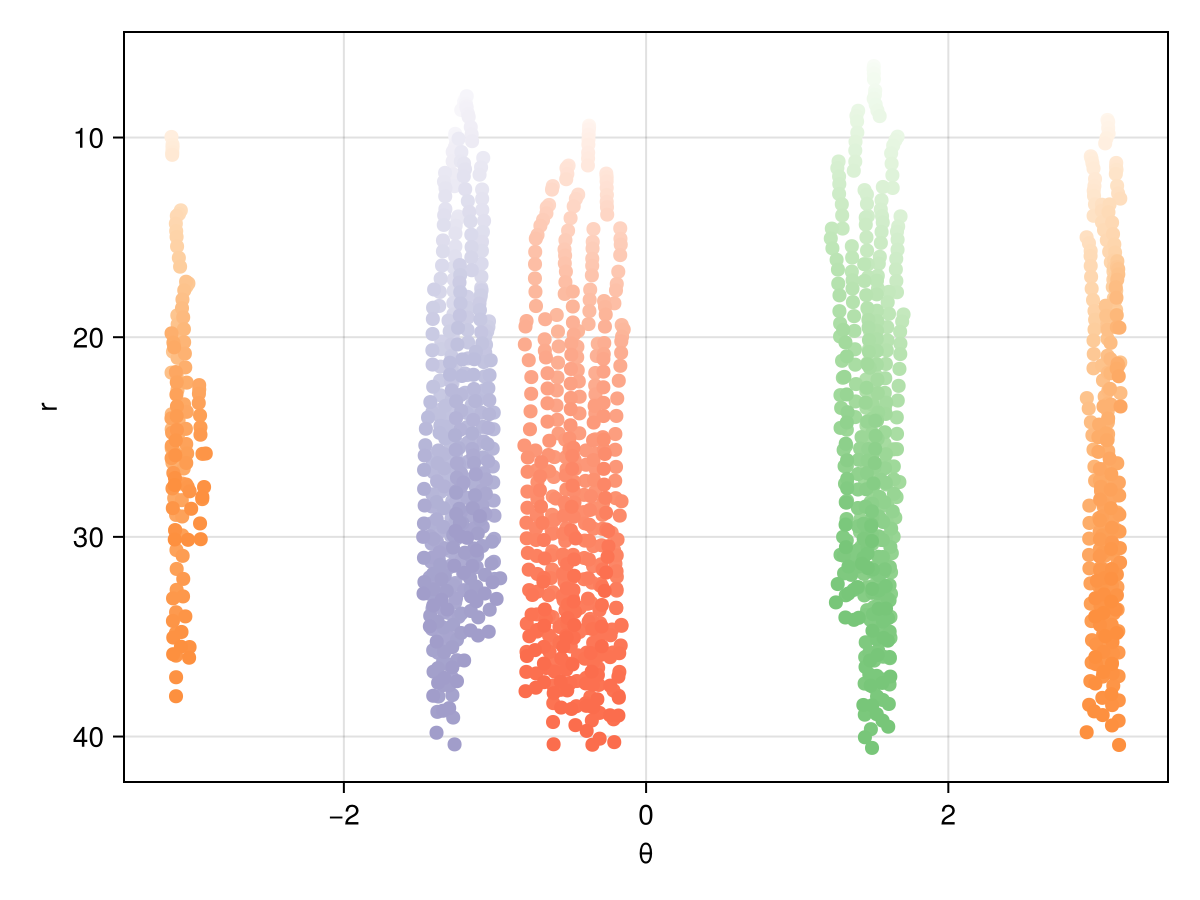

In [28]:
plot_evolution_by_type_from_positions(com_load)

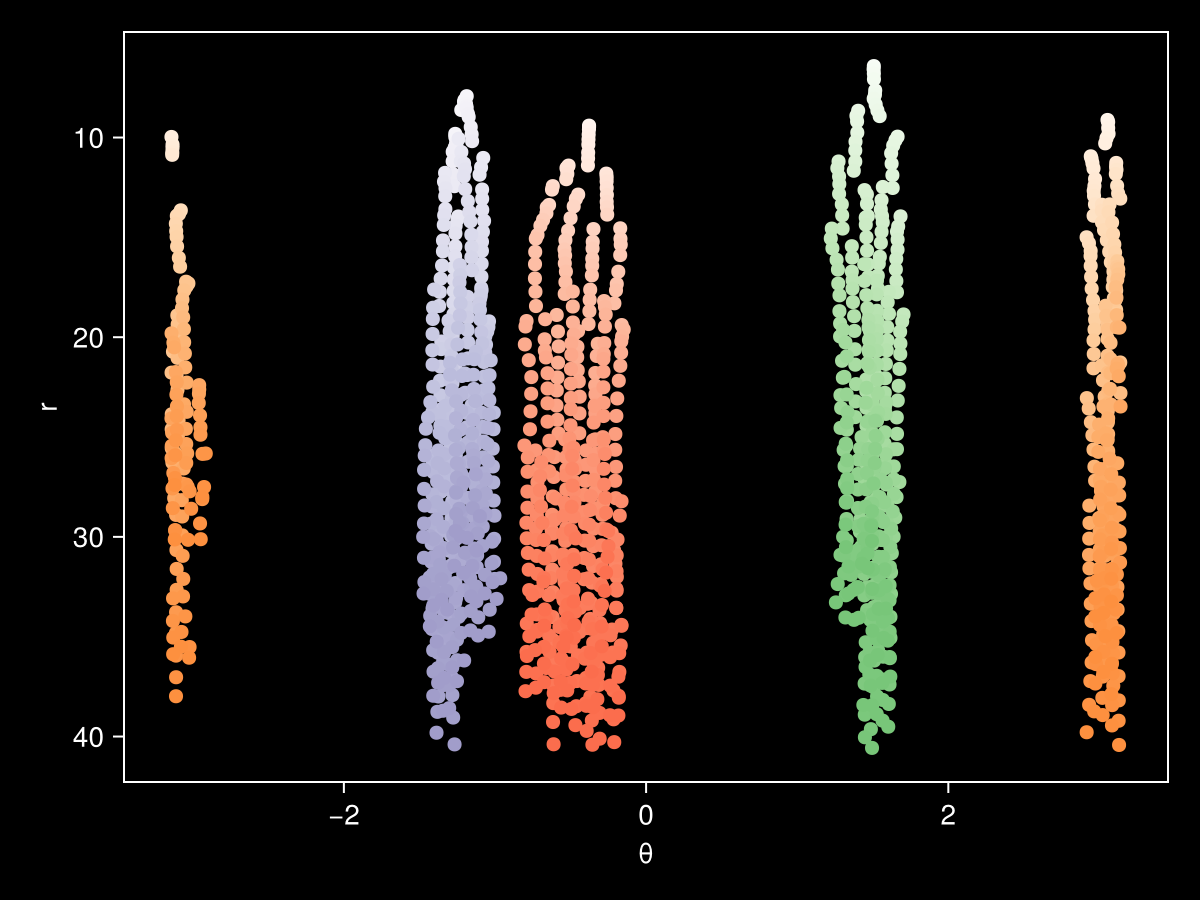

In [31]:
plot_evolution(com_load)


In [75]:

# Crear figura y ejes
fig = Figure(size = (800, 600))
grid = fig[1, 1] = GridLayout()
ax = Axis(grid[1, 1]; aspect = DataAspect())


# colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colorrange = (0.0,  2.)

Makie.record(fig, "Tods_c.mp4", 1:10:Int(length(com_load)); framerate = 15) do j
 
    Makie.empty!(ax)
   
    plotMixedAgents!(
        ax,
        com_load[j][:x],
        com_load[j][:y],
        com_load[j][:d],
        com_load[j][:l],
        com_load[j][:theta],
        com_load[j][:type],
        com_load[j][:d],
        colorrange = colorrange
    )


    xlims!(ax, -50, 50)
    ylims!(ax, -50, 50)
end


"Tods_c.mp4"